In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import KNNImputer,SimpleImputer

In [2]:
df = pd.read_csv('heart_disease.csv')

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [4]:
df.drop(columns='id',inplace=True)

In [5]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [6]:
df.shape

(920, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 100.8+ KB


In [8]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000


In [52]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope       309
ca          611
thal        486
dtype: int64

In [72]:
df.isnull().mean()*100

age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     0.000000
chol         0.000000
fbs          0.000000
restecg      0.000000
thalch       0.000000
exang        0.000000
oldpeak      0.000000
slope       33.586957
ca          66.413043
thal        52.826087
dtype: float64

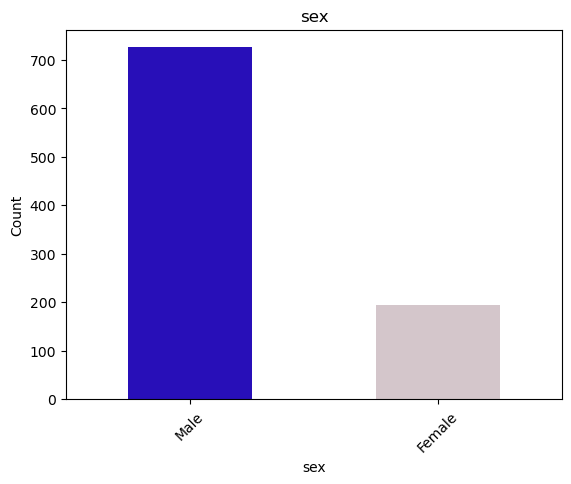

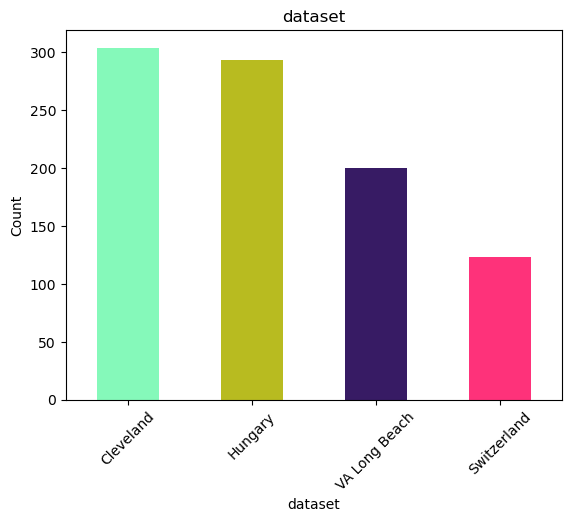

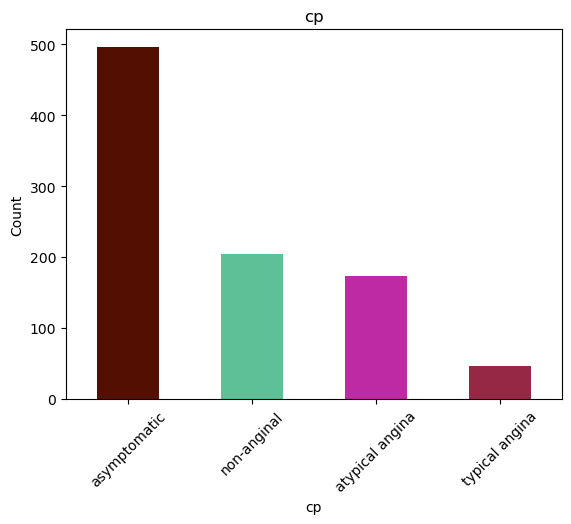

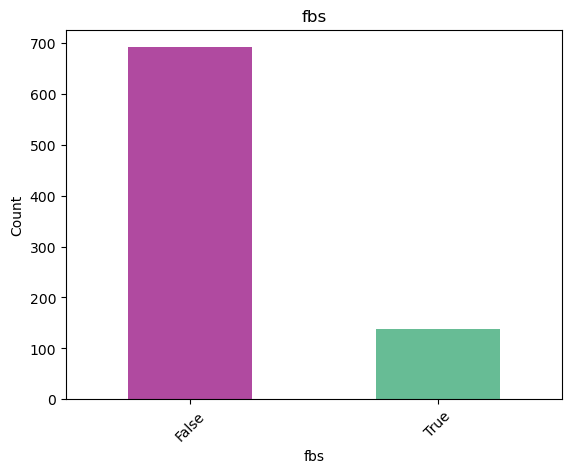

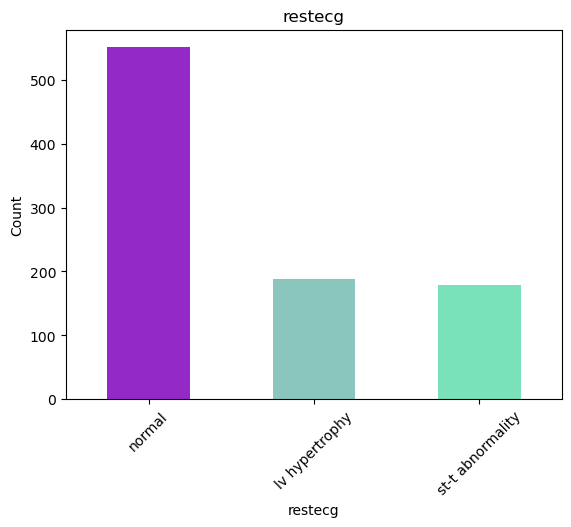

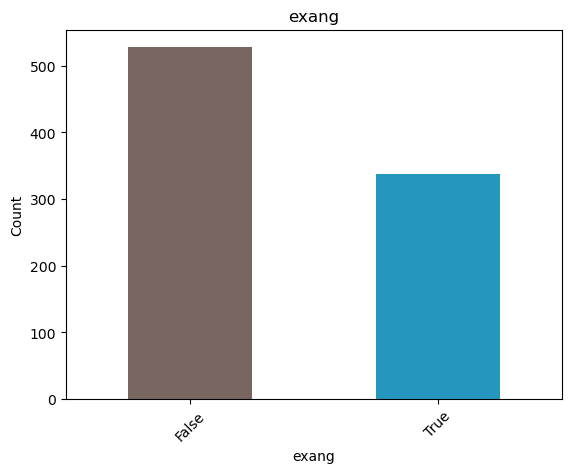

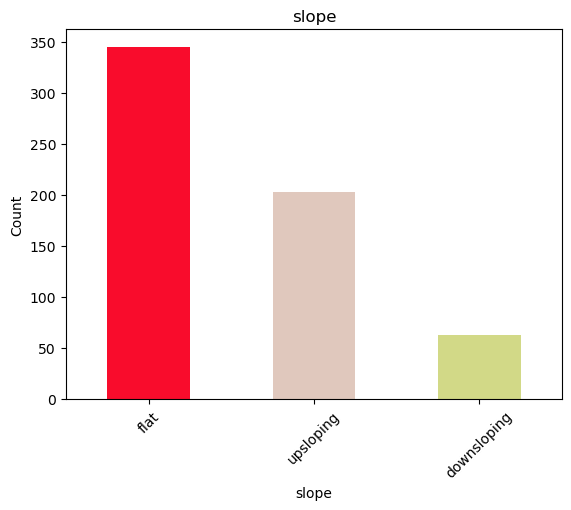

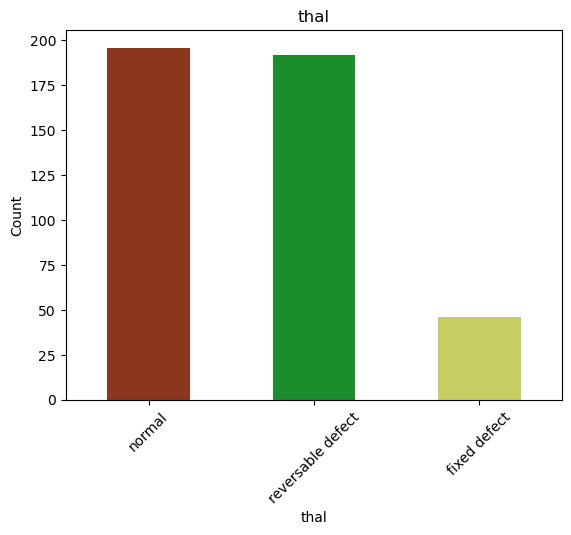

In [11]:
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']  # List of colors
for col in df.select_dtypes(include=['object', 'category']).columns:
    value_counts = df[col].value_counts()
    colors = np.random.rand(len(value_counts), 3)  # Generates random RGB colors
    value_counts.plot(kind='bar', title=col, color=colors)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

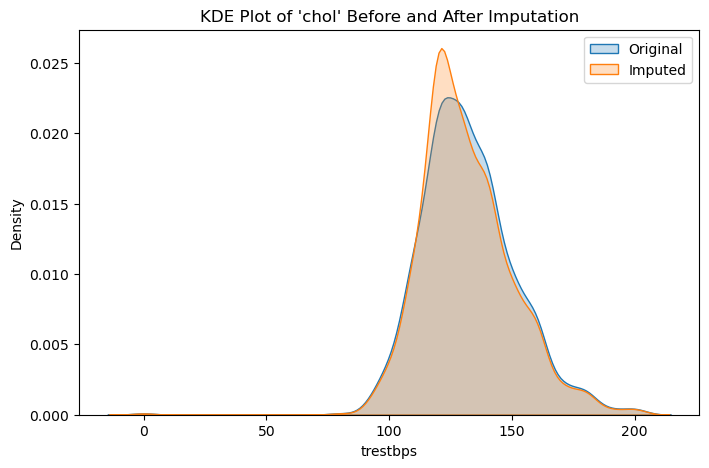

In [12]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df['trestbps'], label='Original', fill=True)  # Plot original distribution
sns.kdeplot(df['trestbps'].fillna(df['trestbps'].mode()[0]), label='Imputed', fill=True)  # Fill NaN with mode

plt.legend()
plt.title("KDE Plot of 'chol' Before and After Imputation")
plt.show()

In [13]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mode()[0])

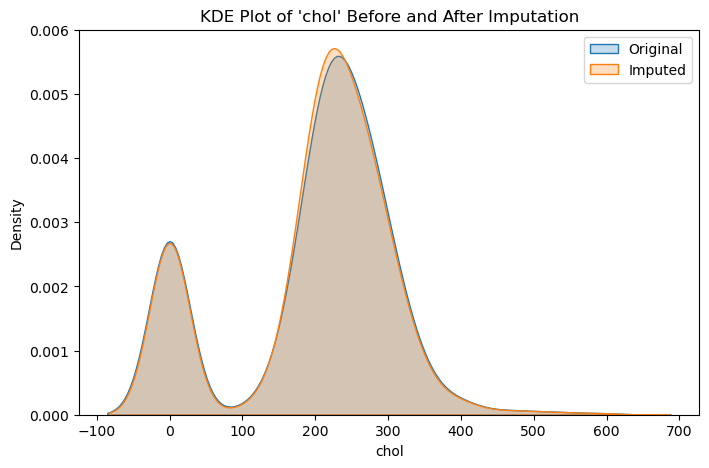

In [14]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df['chol'], label='Original', fill=True)  # Plot original distribution
sns.kdeplot(df['chol'].fillna(df['chol'].mean()), label='Imputed', fill=True)  # Fill NaN with mode

plt.legend()
plt.title("KDE Plot of 'chol' Before and After Imputation")
plt.show()

In [15]:
df['chol'] = df['chol'].fillna(df['chol'].mean())

C:\Users\parvez\AppData\Local\Temp\ipykernel_4880\3735878028.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['fbs'].fillna(method='ffill').value_counts().plot(kind='bar', color='orange', alpha=0.6, label='Imputed (bfill)')
C:\Users\parvez\AppData\Local\Temp\ipykernel_4880\3735878028.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'].fillna(method='ffill').value_counts().plot(kind='bar', color='orange', alpha=0.6, label='Imputed (bfill)')


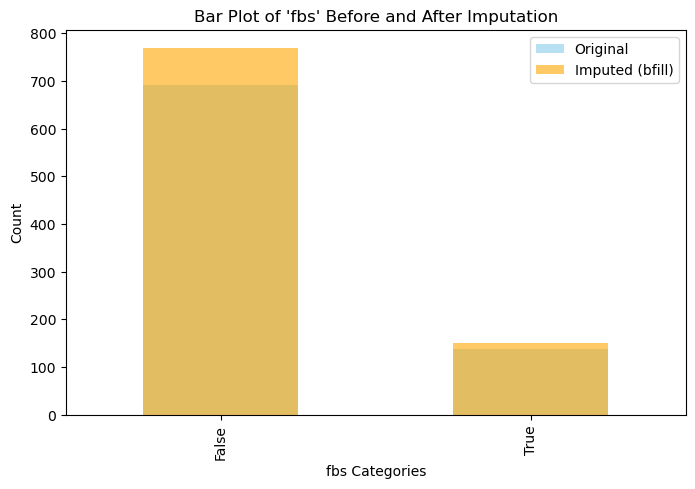

In [16]:
plt.figure(figsize=(8, 5))

# Original distribution
df['fbs'].value_counts().plot(kind='bar', color='skyblue', alpha=0.6, label='Original')

# Imputed distribution using Backward Fill (bfill)
df['fbs'].fillna(method='ffill').value_counts().plot(kind='bar', color='orange', alpha=0.6, label='Imputed (bfill)')

plt.legend()
plt.xlabel("fbs Categories")
plt.ylabel("Count")
plt.title("Bar Plot of 'fbs' Before and After Imputation")
plt.show()

In [17]:
df['fbs']=df['fbs'].fillna(df['fbs'].ffill())

C:\Users\parvez\AppData\Local\Temp\ipykernel_4880\191615884.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs']=df['fbs'].fillna(df['fbs'].ffill())


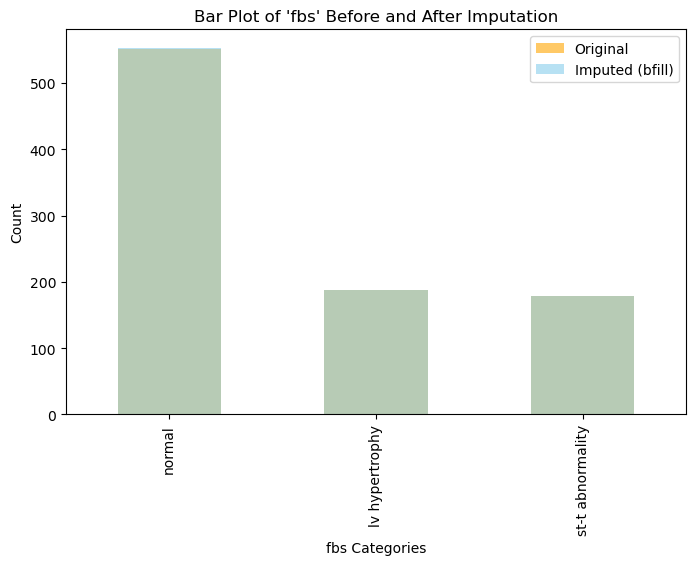

In [18]:
plt.figure(figsize=(8, 5))

# Original distribution
df['restecg'].value_counts().plot(kind='bar', color='orange', alpha=0.6, label='Original')

# Imputed distribution using Backward Fill (bfill)
df['restecg'].fillna(df['restecg'].ffill()).value_counts().plot(kind='bar', color='skyblue', alpha=0.6, label='Imputed (bfill)')

plt.legend()
plt.xlabel("fbs Categories")
plt.ylabel("Count")
plt.title("Bar Plot of 'fbs' Before and After Imputation")
plt.show()

In [19]:
df['restecg']=df['restecg'].fillna(df['restecg'].ffill())

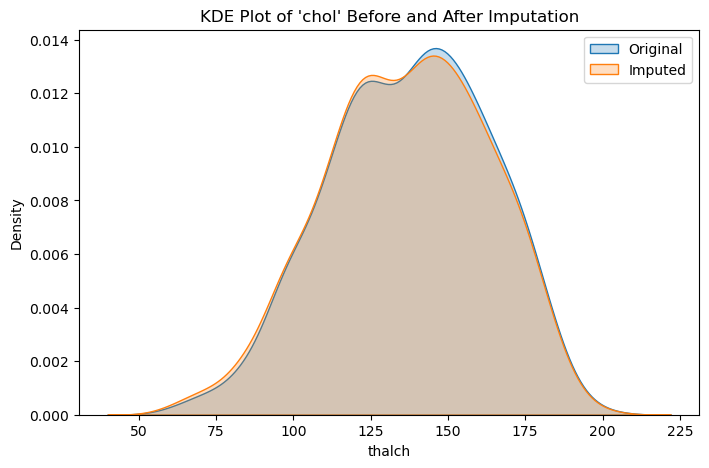

In [20]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df['thalch'], label='Original', fill=True)  # Plot original distribution
# sns.kdeplot(df['thalch'].fillna(df['thalch'].mode()[0]), label='Imputed', fill=True)  # Fill NaN with mode
sns.kdeplot(df['thalch'].interpolate(method='quadratic'), label='Imputed', fill=True)  # Fill NaN with mode

plt.legend()
plt.title("KDE Plot of 'chol' Before and After Imputation")
plt.show()

In [21]:
df['thalch'] = df['thalch'].interpolate(method='quadratic')  # quadratic interpolation

C:\Users\parvez\AppData\Local\Temp\ipykernel_4880\365525531.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'].fillna(df['exang'].ffill()).value_counts().plot(kind='bar', color='skyblue', alpha=0.6, label='Imputed (ffill)')


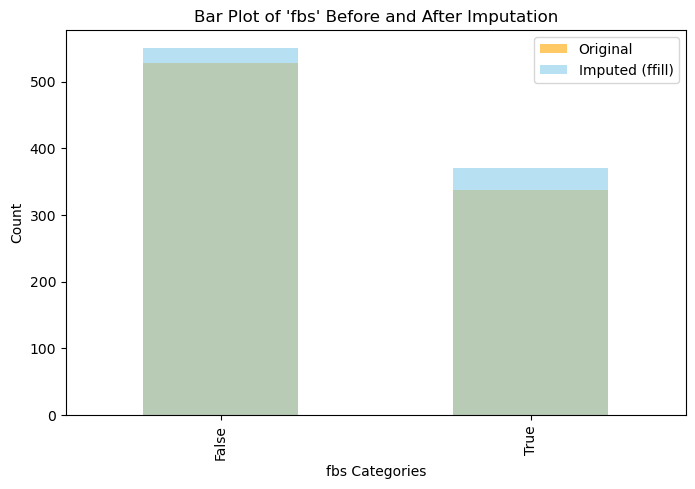

In [22]:
plt.figure(figsize=(8, 5))

# Original distribution
df['exang'].value_counts().plot(kind='bar', color='orange', alpha=0.6, label='Original')

# Imputed distribution using Backward Fill (bfill)
df['exang'].fillna(df['exang'].ffill()).value_counts().plot(kind='bar', color='skyblue', alpha=0.6, label='Imputed (ffill)')

plt.legend()
plt.xlabel("fbs Categories")
plt.ylabel("Count")
plt.title("Bar Plot of 'fbs' Before and After Imputation")
plt.show()

In [23]:
df['exang']=df['exang'].fillna(df['exang'].ffill())

C:\Users\parvez\AppData\Local\Temp\ipykernel_4880\3254071798.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang']=df['exang'].fillna(df['exang'].ffill())


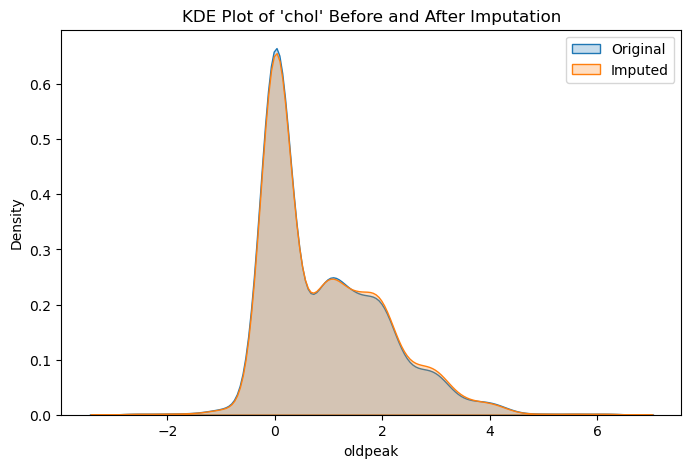

In [24]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df['oldpeak'], label='Original', fill=True)  # Plot original distribution
# sns.kdeplot(df['thalch'].fillna(df['thalch'].mode()[0]), label='Imputed', fill=True)  # Fill NaN with mode
sns.kdeplot(df['oldpeak'].interpolate(method='linear'), label='Imputed', fill=True)  # Fill NaN with mode

plt.legend()
plt.title("KDE Plot of 'chol' Before and After Imputation")
plt.show()

In [25]:
df['oldpeak'] = df['oldpeak'].interpolate(method='linear')  # linear interpolation

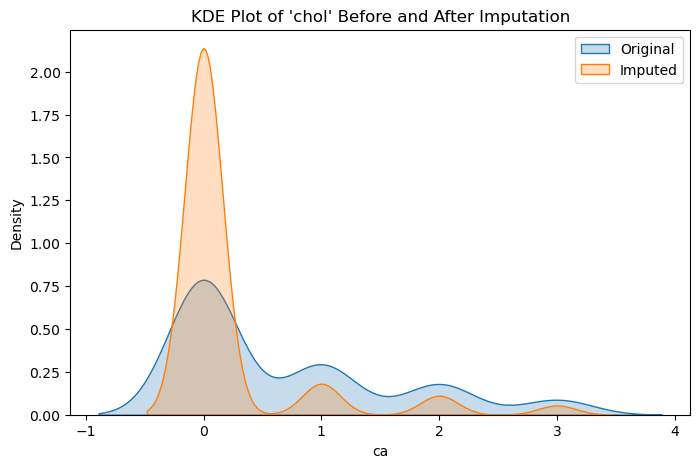

In [98]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df['ca'], label='Original', fill=True)  # Plot original distribution
sns.kdeplot(df['ca'].fillna(df['ca'].median()), label='Imputed', fill=True)  # Fill NaN with mode
# sns.kdeplot(df['ca'].interpolate(method='quadratic'), label='Imputed', fill=True)  # Fill NaN with mode

plt.legend()
plt.title("KDE Plot of 'chol' Before and After Imputation")
plt.show()

In [100]:
df[df['ca'].isnull()]['ca']

166   NaN
192   NaN
287   NaN
302   NaN
303   NaN
       ..
915   NaN
916   NaN
917   NaN
918   NaN
919   NaN
Name: ca, Length: 611, dtype: float64